In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_excel('rawdata.xls',header=1)

In [6]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [7]:
df_updated=df.copy()

In [8]:
df_updated.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [9]:
df_updated.drop(columns=['ID'], inplace=True)


In [10]:
df_updated = df_updated.rename(columns={'default payment next month': 'default_payment'})

### SMOTE(Synthetic Minority OverSampling Technique)

In [11]:
df_updated.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [12]:
x=df_updated.drop(columns=['default_payment'],axis=1)
y=df_updated['default_payment']

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

- Target data is highly iimbalanced so using SMOTE technique

The target variable is imbalanced, with non-default cases significantly outnumbering default cases. Such imbalance can bias machine learning models toward the majority class and reduce minority class detection capability. SMOTE was applied only on the training dataset to synthetically balance the minority class while preventing data leakage.

In [15]:
## Pipeline for Logistic Regression
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_scaled_smote,y_train_smote=smote.fit_resample(x_train_scaled,y_train)

In [16]:
## Pipeline for Ensemble techniques
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)

- Target Value got balanced

#### Comparing before and after SMOTE of target varible

C:\Users\PRIYAM KUMAR DE\AppData\Local\Temp\ipykernel_3292\4037517446.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\PRIYAM KUMAR DE\AppData\Local\Temp\ipykernel_3292\4037517446.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


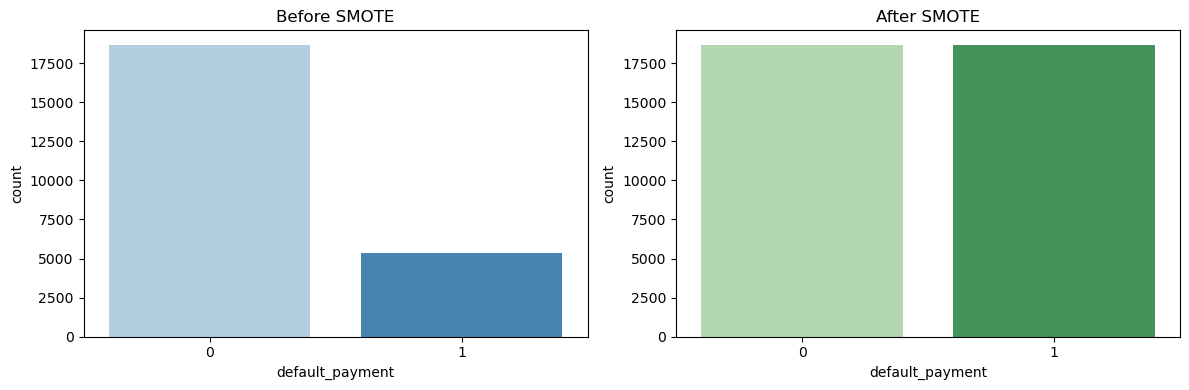

In [17]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,4)
)

# Before SMOTE
sns.countplot(
    x=y_train,
    ax=axes[0],
    palette='Blues'
)

axes[0].set_title('Before SMOTE')

# After SMOTE
sns.countplot(
    x=y_train_smote,
    ax=axes[1],
    palette='Greens'
)

axes[1].set_title('After SMOTE')

plt.tight_layout()

plt.show()

# Separate Preprocessing Pipelines

Different preprocessing pipelines were created based on the requirements of the machine learning algorithms used in this project.

---

## 1. Scaled Pipeline for Logistic Regression

Logistic Regression is sensitive to feature magnitude because it relies on mathematical optimization and coefficient calculations.

Financial variables in the dataset contain large differences in scale, such as:

- AGE
- LIMIT_BAL
- BILL_AMT
- PAY_AMT

Without scaling, features with larger numerical ranges may dominate the learning process and negatively affect model performance.

Therefore, `StandardScaler` was applied before training Logistic Regression.

## 2. Unscaled Pipeline for Random Forest and XGBoost

Random Forest and XGBoost are tree-based ensemble models that are not sensitive to feature magnitude.

These algorithms make predictions using decision-tree splits rather than distance-based calculations. As a result, scaling is generally unnecessary for such models.

To maintain a simpler and more efficient preprocessing workflow, feature scaling was not applied for Random Forest and XGBoost.

In [18]:
import joblib

joblib.dump(
    x_train_scaled_smote,
    'data/processed/x_train_scaled_smote.pkl'
)

joblib.dump(
    x_test_scaled,
    'data/processed/x_test_scaled.pkl'
)

['data/processed/x_test_scaled.pkl']

In [19]:
joblib.dump(
    x_train_smote,
    'data/processed/x_train_smote.pkl'
)

joblib.dump(
    x_test,
    'data/processed/x_test.pkl'
)

['data/processed/x_test.pkl']

In [20]:
joblib.dump(
    y_train_smote,
    'data/processed/y_train_smote.pkl'
)

joblib.dump(
    y_test,
    'data/processed/y_test.pkl'
)

['data/processed/y_test.pkl']

In [21]:
joblib.dump(scaler,
            'models/scaler.pkl')

['models/scaler.pkl']

In [23]:
df_updated.to_excel(
    'data/cleaned_dataset.xlsx',
    index=False
)